# Nigerian Language Identifier

**Problem:** Many apps that serve Nigerian users need to know what language a piece of text is written in — Yoruba, Hausa, Igbo, or English — before they can translate it, route it, or respond appropriately.

**Goal:** Train a machine learning model that takes a short phrase of text and predicts which of these four languages it's written in.

**Approach:** Using a public multi-language dataset, this notebook extracts character- and word-level patterns from text (TF-IDF) and trains a Logistic Regression classifier to distinguish between the four languages. The model achieves 99.9% accuracy on held-out test data, with a documented limitation on very short, informal phrases.

In [ ]:
!pip install datasets scikit-learn pandas joblib -q

Step 1: Install required packages

In [ ]:
from datasets import load_dataset
import pandas as pd

languages = {"hausa": "Hausa", "igbo": "Igbo", "yoruba": "Yoruba", "english": "English"}
all_data = []

for code, name in languages.items():
    ds = load_dataset("benjaminogbonna/nigerian_common_voice_dataset", code)
    for split in ds.keys():
        df = ds[split].to_pandas()
        df["language"] = name
        df["split_source"] = split
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)
data = data[["sentence", "language"]]  # we only need the text and its label now
print("Total rows loaded:", len(data))
print(data["language"].value_counts())
data.head()

README.md:   0%|          | 0.00/13.3k [00:00<?, ?B/s]

hausa/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  188MB            

hausa/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

hausa/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.1MB            

hausa/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/2721 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/340 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/341 [00:00<?, ? examples/s]

Total rows loaded: 22295
language
Hausa      9008
Igbo       5714
Yoruba     4171
English    3402
Name: count, dtype: int64


,sentence,language
0,Bude kofar. Na san kina ciki.,Hausa
1,Na ga wani aikin dabba mai ban mamaki a circus.,Hausa
2,Shin kun yarda ko baku yarda ba?,Hausa
3,Kun ce zaku taimaka musu.,Hausa
4,Sun dauki fim din a ainihin sahara.,Hausa


## Step 2: Load and prepare the dataset

We use a public Hugging Face dataset containing labeled text in Hausa, Igbo, Yoruba, and English.

In [ ]:
print(data["language"].value_counts())

language
Hausa      9008
Igbo       5714
Yoruba     4171
English    3402
Name: count, dtype: int64


### Step 3: Split data into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data["sentence"], data["language"], test_size=0.2, random_state=42
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 17836
Testing examples: 4459


## Step 4: Convert text into numerical features (TF-IDF)

We combine character-level and word-level patterns to capture both spelling/diacritic differences and whole-word cues.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Character-level patterns (as before, but slightly wider range)
char_vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(1, 4), max_features=5000)

# Word-level patterns (new) - helps catch whole short words like "Kedu" or "Bawo"
word_vectorizer = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), max_features=2000)

# Fit both on training data
X_train_char = char_vectorizer.fit_transform(X_train)
X_train_word = word_vectorizer.fit_transform(X_train)

# Combine them into one feature set
X_train_combined = hstack([X_train_char, X_train_word])

# Do the same transform (not fit) on test data
X_test_char = char_vectorizer.transform(X_test)
X_test_word = word_vectorizer.transform(X_test)
X_test_combined = hstack([X_test_char, X_test_word])

print("Combined training shape:", X_train_combined.shape)

Combined training shape: (17836, 7000)


## Step 5: Train the classifier and evaluate accuracy

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train_combined, y_train)

y_pred = model.predict(X_test_combined)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9993272034088361

              precision    recall  f1-score   support

     English       1.00      1.00      1.00       656
       Hausa       1.00      1.00      1.00      1853
        Igbo       1.00      1.00      1.00      1111
      Yoruba       1.00      1.00      1.00       839

    accuracy                           1.00      4459
   macro avg       1.00      1.00      1.00      4459
weighted avg       1.00      1.00      1.00      4459



## Confusion Matrix

Visualizes exactly which languages the model confuses with each other, if any.

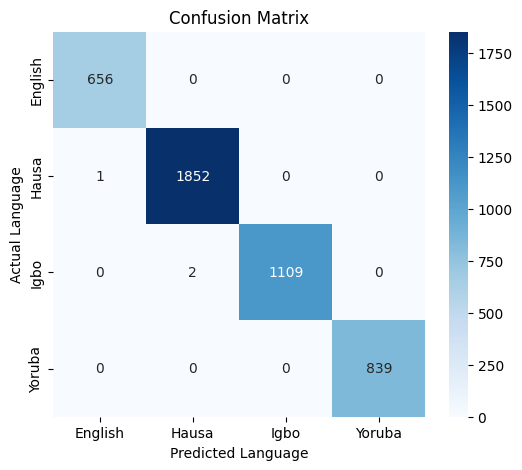

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted Language")
plt.ylabel("Actual Language")
plt.title("Confusion Matrix")
plt.show()

## Step 6: Test the model on custom phrases

In [ ]:
def predict_language(text):
    char_vec = char_vectorizer.transform([text])
    word_vec = word_vectorizer.transform([text])
    combined_vec = hstack([char_vec, word_vec])

    prediction = model.predict(combined_vec)[0]
    probabilities = model.predict_proba(combined_vec)[0]
    confidence = max(probabilities) * 100

    return prediction, confidence

# Test it
for phrase in ["Bawo ni?", "Kedu", "Nagode", "How are you doing today"]:
    lang, conf = predict_language(phrase)
    print(f"'{phrase}' → {lang} ({conf:.1f}% confidence)")

'Bawo ni?' → Hausa (59.9% confidence)
'Kedu' → Igbo (75.0% confidence)
'Nagode' → Igbo (88.3% confidence)
'How are you doing today' → English (97.9% confidence)


## Step 7: Interactive demo

Type a phrase below to see the model predict its language live.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

text_input = widgets.Text(
    placeholder="Type a phrase in English, Hausa, Igbo, or Yoruba...",
    description="Text:",
    layout=widgets.Layout(width="500px")
)
button = widgets.Button(description="Detect Language")
output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        text = text_input.value
        if text.strip() == "":
            print("Please type something first.")
        else:
            prediction, confidence = predict_language(text)
            print(f"Predicted language: {prediction} ({confidence:.1f}% confidence)")

button.on_click(on_button_click)

display(text_input, button, output)

Text(value='', description='Text:', layout=Layout(width='500px'), placeholder='Type a phrase in English, Hausa…

Button(description='Detect Language', style=ButtonStyle())

Output()

## Step 8: Save the trained model for reuse outside this notebook

In [ ]:
import joblib

joblib.dump(model, "language_model.pkl")
joblib.dump(char_vectorizer, "char_vectorizer.pkl")
joblib.dump(word_vectorizer, "word_vectorizer.pkl")

print("Saved all 3 files!")

Saved all 3 files!


In [ ]:
from google.colab import files

files.download("language_model.pkl")
files.download("char_vectorizer.pkl")
files.download("word_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>